In [ ]:
Projects
1. Customer Segmentation
Objective: Use K-Means to segment customers based on purchasing behavior.
Dataset: Retail customer dataset with features like age, spending score, and income.
Instructions:
Load the dataset and preprocess the data (handle missing values and scale numerical features).
Apply K-Means to group customers into clusters.
Visualize the clusters and analyze the types of customers in each group.
Level 1: Basic Understanding - Load, Preprocess, and Visualize
Objective: Load a retail customer dataset, preprocess the data, and apply basic K-Means clustering.
Instructions: Load the Dataset: Load a simple retail customer dataset containing age, income, and spending score.
Preprocess the Data: Clean up missing values and scale the numerical data.
Apply K-Means Clustering: Perform basic K-Means clustering on the dataset.
Visualize the Clusters: Plot the results to visually separate the clusters.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
# 1. Load the dataset
data = pd.read_csv("retail_customers.csv")
print(data.head())

In [ ]:
# 2. Preprocess the data (handling missing values and scaling)
data = data.dropna()  # Removing missing values
features = data[['Age', 'Income', 'SpendingScore']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
# 3. Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
# 4. Visualize the clusters
plt.scatter(data['Age'], data['Income'], c=data['Cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Customer Segmentation')
plt.show()

In [ ]:
Outcome: You'll have a basic plot showing customer segmentation based on age and income, with 3 clusters.

In [1]:
Level 2: Intermediate - Elbow Method for Optimal Clusters
Objective: Use the Elbow Method to determine the optimal number of clusters for K-Means.
Instructions: Elbow Method: Use the Elbow Method to find the best number of clusters.
Visualize the Elbow Curve: Plot the WCSS (Within-Cluster Sum of Squares) to decide the ideal number of clusters.

   CustomerID  Age  Income  SpendingScore
0           1   56   94740             28
1           2   69   86617             74
2           3   46  114841             39
3           4   32   36896             57
4           5   60   66175             17


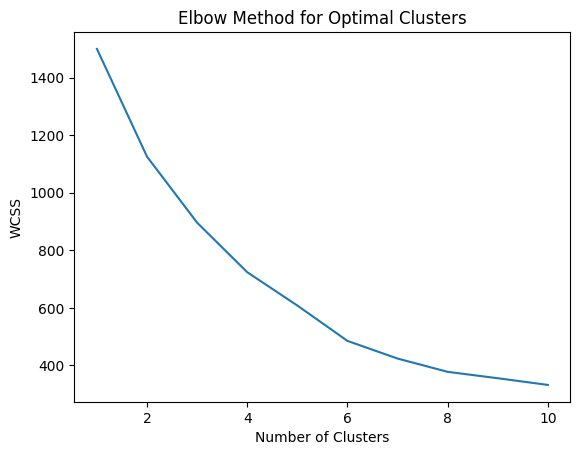

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)                                              # Set the seed for reproducibility
num_customers = 500                                             # Generate random data
ages = np.random.randint(18, 71, num_customers)                 # Age: Randomly between 18 and 70
income = np.random.randint(20000, 120001, num_customers)        # Income: Randomly between 20,000 and 120,000
spending_score = np.random.randint(1, 101, num_customers)       # SpendingScore: Randomly between 1 and 100

# Create a DataFrame
data = pd.DataFrame({
    'CustomerID': range(1, num_customers + 1),
    'Age': ages,
    'Income': income,
    'SpendingScore': spending_score
})

data.to_csv('retail_customers.csv', index=False)  # Save the dataset to a CSV file
print(data.head())    # Display the first few rows

# Preprocess the data (handling missing values and scaling)
data = data.dropna()  # Removing missing values, ensure you handle NaN values appropriately
features = data[['Age', 'Income', 'SpendingScore']]  # Use relevant features

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Calculate WCSS (Within-Cluster Sum of Squares) for different numbers of clusters
wcss = []
for i in range(1, 11):  # Trying cluster sizes from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)  # Fit the model
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS

# Plot the Elbow Curve
plt.plot(range(1, 11), wcss)  # Plot number of clusters vs. WCSS
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [1]:
Outcome: The plot will show an "elbow," helping you choose the optimal number of clusters.

In [1]:
Level 3: Advanced - Analyzing Customer Segments with Cluster Centers
Objective: Identify the characteristics of each customer segment (cluster) using the cluster centers.
Instructions: Analyze the Cluster Centers: Find the cluster centers (mean values for each cluster).
Interpret Customer Segments: Based on the cluster centers, label each cluster with a descriptive name (ex: "Low Income", "High Spending").

In [3]:
# 1. Fit K-Means with optimal clusters (from Elbow Method)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

# 2. Analyze Cluster Centers
centers = kmeans.cluster_centers_
print("Cluster Centers:")
print(centers)

# 3. Assign descriptive names to clusters based on cluster centers
cluster_labels = {0: 'Low Income, Low Spending', 1: 'Middle Income, Average Spending', 2: 'High Income, High Spending'}
data['Cluster_Description'] = data['Cluster'].map(cluster_labels)

# 4. Display the results
print(data.head())

Cluster Centers:
[[-0.09653044 -0.05171212 -0.9864149 ]
 [ 0.94003193  0.03773748  0.58643492]
 [-0.9623795   0.03189865  0.76525392]]
   CustomerID  Age  Income  SpendingScore  Cluster  \
0           1   56   94740             28        0   
1           2   69   86617             74        1   
2           3   46  114841             39        0   
3           4   32   36896             57        2   
4           5   60   66175             17        0   

               Cluster_Description  
0         Low Income, Low Spending  
1  Middle Income, Average Spending  
2         Low Income, Low Spending  
3       High Income, High Spending  
4         Low Income, Low Spending  


In [1]:
Outcome: Each customer will be assigned a descriptive cluster label based on their characteristics.

In [ ]:
Level 4: Expert - Visualizing High-Dimensional Data
Objective: Cluster customers in a higher-dimensional space (e.g., adding more features) and visualize the results.
Instructions: Add More Features: Add new features to the dataset like customer loyalty, frequency of purchase, etc.
Dimensionality Reduction: Use PCA (Principal Component Analysis) to reduce dimensionality for visualization.
Plot the Reduced Dimensions: Visualize the high-dimensional clustering results.

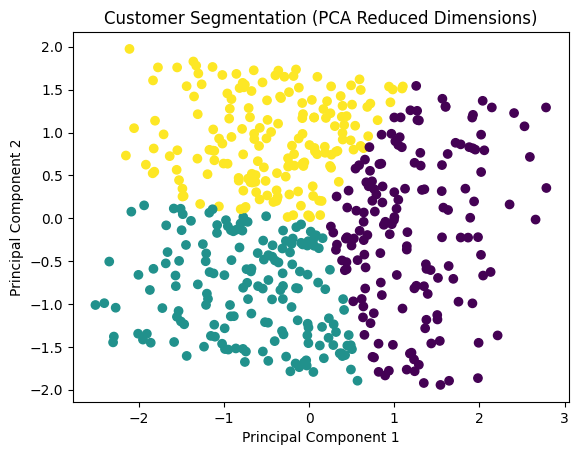

In [4]:

from sklearn.decomposition import PCA

# 1. Add new features (Example: Frequency of Purchase)
data['Frequency'] = np.random.randint(1, 10, size=len(data))  # Simulating a new feature

# 2. Scale the data (include new feature)
features = data[['Age', 'Income', 'SpendingScore', 'Frequency']]
scaled_features = scaler.fit_transform(features)

# 3. Apply PCA to reduce dimensions for visualization (from 4D to 2D)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# 4. Apply K-Means with the reduced features
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(pca_features)

# 5. Plot the clusters
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=data['Cluster'], cmap='viridis')
plt.title('Customer Segmentation (PCA Reduced Dimensions)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
Outcome: The high-dimensional clustering result will be visualized in 2D after applying PCA.

In [ ]:
Level 5: Master - Evaluating the Model and Improving Performance
Objective: Evaluate clustering performance using Silhouette Score and improve the model with Mini-Batch K-Means for large datasets.
Instructions: Silhouette Score: Calculate and interpret the silhouette score for evaluating cluster quality.
Use Mini-Batch K-Means: Apply Mini-Batch K-Means to speed up clustering on large datasets.


In [6]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

# 1. Apply Mini-Batch K-Means for faster clustering on large datasets
minibatch_kmeans = MiniBatchKMeans(n_clusters=3, random_state=42)
data['Cluster'] = minibatch_kmeans.fit_predict(scaled_features)

# 2. Calculate Silhouette Score for model evaluation
score = silhouette_score(scaled_features, data['Cluster'])
print(f'Silhouette Score: {score}')

# 3. If silhouette score is low, experiment with different numbers of clusters
minibatch_kmeans = MiniBatchKMeans(n_clusters=4, random_state=42)
data['Cluster'] = minibatch_kmeans.fit_predict(scaled_features)
score = silhouette_score(scaled_features, data['Cluster'])
print(f'Silhouette Score for 4 Clusters: {score}')

Silhouette Score: 0.1792529841783302
Silhouette Score for 4 Clusters: 0.17417653813040976


In [ ]:
Outcome: The silhouette score will give you an idea of how well-defined the clusters are. Mini-Batch K-Means improves the efficiency for large datasets.

# THE END